# Markov Chains

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sb
import xarray as xr
from typing import List, Dict, Callable, Optional
from dataclasses import dataclass
import networkx as nx
from statsconcepts.markov import DiscreteRandomVariable, InitialDistribution, TransitionProbability, MarkovChain

%load_ext autoreload
%autoreload 1
%aimport statsconcepts.markov

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Simulation

Suppose $X$ is a random variable with $P[X = k] = a_k, \quad k \ge 0, \quad \Sigma_{i=0}^\infty a_i = 0$. For example...

In [13]:
x: Dict[int, float] = {0: 0.1, 1: 0.15, 2: 0.3, 3: 0.2, 4: 0.1, 5: 0.08, 6: 0.07}
sum(x.values())

1.0

How might we simulate this distribution? First we need an indicator function built using the event space and probability distribution of the random variable.

In [14]:
DiscreteRandomVariable.indicator_f??

Signature: DiscreteRandomVariable.indicator_f(self) -> Callable[[float], Optional[int]]
Docstring: <no docstring>
Source:   
    def indicator_f(self) -> Callable[[float], Optional[int]]:
        print(self.rv)
        cum_rv: Dict[int, float] = dict(zip(self.rv.keys(), np.cumsum(list(self.rv.values()))))

        def ind(u: float) -> Optional[int]:
            for k, v in cum_rv.items():
                if u <= v:
                    return k
        return ind
File:      ~/projects/statsConcepts/statsconcepts/markov.py
Type:      function

In [15]:
x_rv: DiscreteRandomVariable = DiscreteRandomVariable(x)
ind_x: Callable[[float], int] = x_rv.indicator_f()
ind_x(0.25), ind_x(0.26)

{0: 0.1, 1: 0.15, 2: 0.3, 3: 0.2, 4: 0.1, 5: 0.08, 6: 0.07}


(1, 2)

Now we can just feed out indicator random variables from a uniform distribution and get out our target distribution.

{0: 0.1, 1: 0.15, 2: 0.3, 3: 0.2, 4: 0.1, 5: 0.08, 6: 0.07}


Text(0.5, 1.0, 'Simulated Distribution (n=2000)')

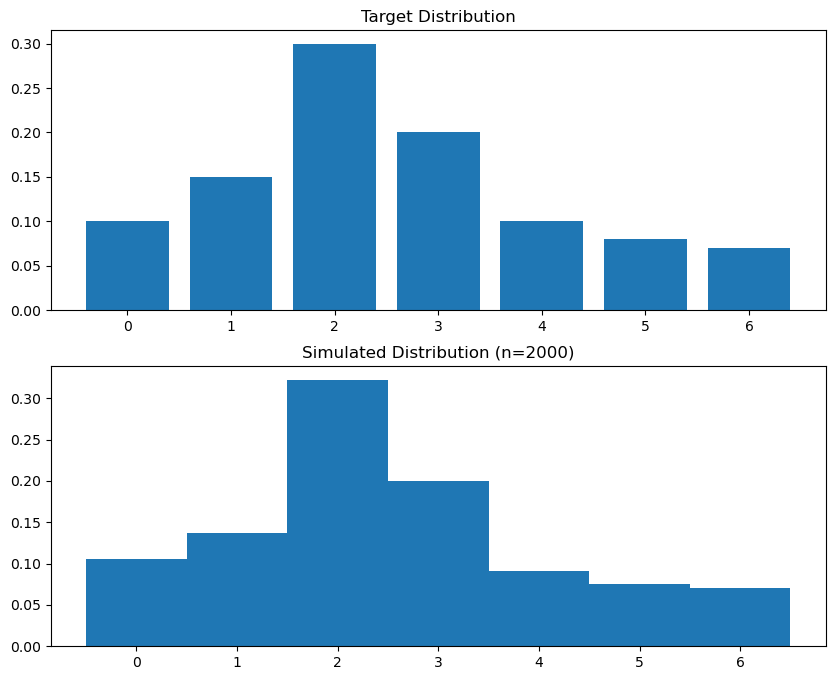

In [16]:
x_sim: List[int] = x_rv.sample(2000)
fig, ax = plt.subplots(2, figsize=(10, 8))
ax[0].bar(x.keys(), x.values())
ax[0].set_title("Target Distribution")
ax[1].hist(x_sim, bins=np.arange(-0.5, 7.5, 1), density=True)
ax[1].set_title("Simulated Distribution (n=2000)")

 This is rather convenient, because now we can just uniformly draw from our simulated data and the target distribution is respected. We can use this same machinery to define the initial distribution among states, as well as the probability of transition between states.

## Markov Construction

To keep this simple, suppose we only have 3 states: A, B, C. Let us define the initial position and transition probabilities. In so doing, we completely define our analytical input parameters.

In [17]:
states: Dict[str, int] = {"A": 0, "B": 1, "C": 2, "D": 3}
initial_dist_dict: Dict[str, float] = {"A": 0.5, "B": 0.3, "C": 0.2, "D": 0.0}
transition_prob: Dict[str, Dict[int, float]] = {
    "A": {"A": 0.6, "B": 0.3, "C": 0.1, "D": 0.0},
    "B": {"A": 0.2, "B": 0.4, "C": 0.3, "D": 0.1},
    "C": {"A": 0.1, "B": 0.3, "C": 0.5, "D": 0.1},
    "D": {"A": 0.0, "B": 0.0, "C": 0.0, "D": 1.0}, # Absorbing state
}

Our initial distribution sets how the population is distributed at time 0.

{'A': 0.5, 'B': 0.3, 'C': 0.2, 'D': 0.0}


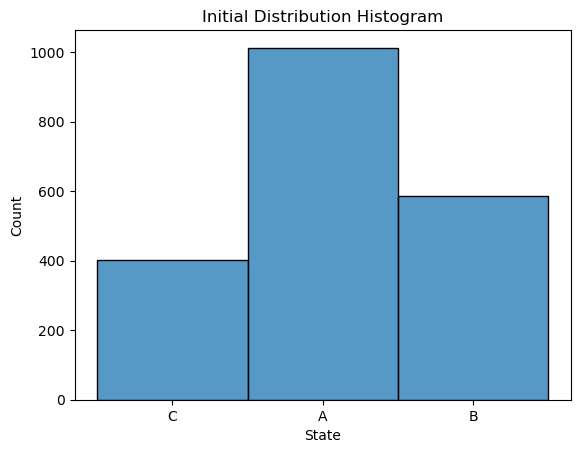

In [18]:
drv_initial: DiscreteRandomVariable = DiscreteRandomVariable(initial_dist_dict)
initial_dist: InitialDistribution = InitialDistribution(
    drv=drv_initial,
    states=states,
    n_draws=2000
)
initial_array: xr.DataArray = initial_dist.to_array()
initial_dist.draw_hist()

The transitions in our simple three state world can be shown graphically.

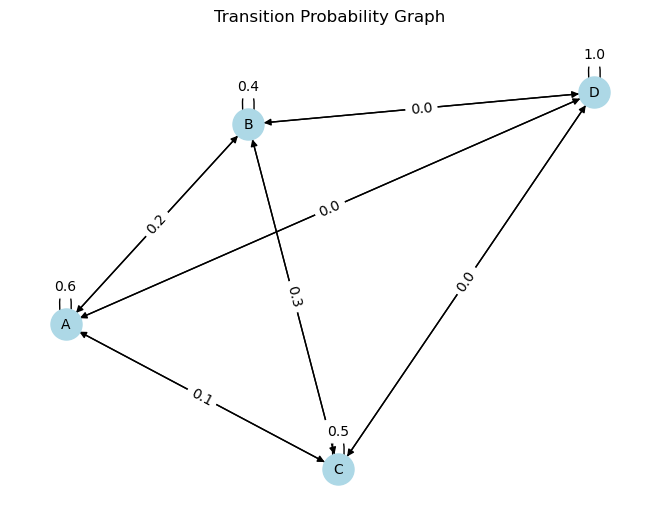

In [19]:
transition_probs: List[TransitionProbability] = TransitionProbability.dict_to_list(transition_prob=transition_prob)
transition_matrix: xr.DataArray = TransitionProbability.to_array(
    tps=transition_probs,
    states=states
)
TransitionProbability.draw_graph(transition_probs)

For our purposes, we are also interested in modeling an inflow in each time period. Our absorbing state $D$ will grow over time, but we are most interested in the composition of our transition states: $A$, $B$, and $C$.

In [20]:
inflow: xr.DataArray = xr.DataArray(
    np.array([[90], [55], [45], [0]]),
    coords=[list(states.keys()), [0]],
    dims=["from_state", "time"]
)
inflow

<xarray.DataArray (from_state: 4, time: 1)> Size: 32B
array([[90],
       [55],
       [45],
       [ 0]])
Coordinates:
  * from_state  (from_state) <U1 16B 'A' 'B' 'C' 'D'
  * time        (time) int64 8B 0

We are now ready to construct our Markov Chain. We can use it to understand the implications for the distribution of our population in each time period over an arbitrary number of time steps. Below, we model a population of 2000 entities and their composition over 10 time steps.

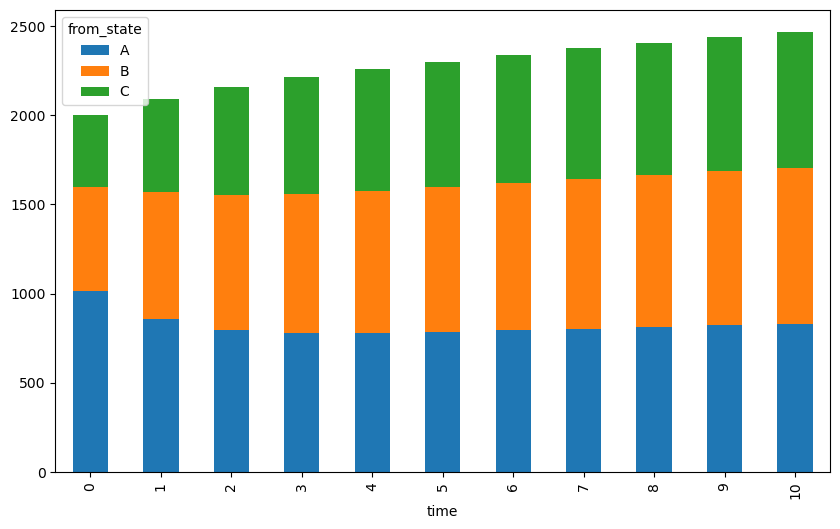

In [21]:
mc: MarkovChain = MarkovChain(
    initial_dist=initial_dist,
    transition_probabilities=TransitionProbability.dict_to_list(transition_prob=transition_prob)
)
mc_sim: xr.DataArray = mc.simulate(n_steps=10, inflow=inflow)
MarkovChain.draw_state_composition(mc_sim, states=["A", "B", "C"])

Finally, we still have all the data from the entire run, and can perform arbitrary follow on analysis as desired.

In [22]:
mc_sim

<xarray.DataArray (from_state: 4, time: 11)> Size: 352B
array([[1013.        ,  855.1       ,  798.04      ,  780.163     ,
         779.021     ,  784.99484   ,  793.777741  ,  803.4335913 ,
         813.10405465,  822.42215285,  831.24425637],
       [ 586.        ,  713.6       ,  753.75      ,  777.679     ,
         796.2827    ,  812.19648   ,  826.401667  ,  839.353829  ,
         851.2910112 ,  862.35217433,  872.62910496],
       [ 401.        ,  522.6       ,  605.89      ,  653.874     ,
         683.257     ,  703.41541   ,  718.866133  ,  731.7313407 ,
         743.01517818,  753.20529791,  762.55051654],
       [   0.        ,   98.7       ,  222.32      ,  358.284     ,
         501.4393    ,  649.39327   ,  800.954459  ,  955.481239  ,
        1112.58975597, 1272.02037491, 1433.57612213]])
Coordinates:
  * from_state  (from_state) <U1 16B 'A' 'B' 'C' 'D'
  * time        (time) int64 88B 0 1 2 3 4 5 6 7 8 9 10